# Notebook 3: Explainability & Risk Bands

SHAP values, individual prediction explanations, and interpretable risk-band recommendations.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from src.data_processing import TARGET_COL
from src.features import get_numeric_features
from src.evaluation import assign_risk_bands, recommend_action, risk_band_summary

plt.rcParams['figure.dpi'] = 110

## 2. Load Data & Model

In [2]:
df = pd.read_parquet('../data/processed/features.parquet')
FEATURES = get_numeric_features(df)
X = df[FEATURES]
y = df[TARGET_COL]

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

xgb = joblib.load('../outputs/models/xgboost.pkl')
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print(f"Loaded model. Test samples: {len(X_test):,}")

Loaded model. Test samples: 29,998


## 3. SHAP Global Importance

SHAP assigns each feature a contribution to each prediction. The summary plot shows which features matter most and their direction of effect.

 75%|===============     | 1509/2000 [00:11<00:03]       

 82%|================    | 1646/2000 [00:12<00:02]       

 90%|==================  | 1795/2000 [00:13<00:01]       

 97%|=================== | 1945/2000 [00:14<00:00]       

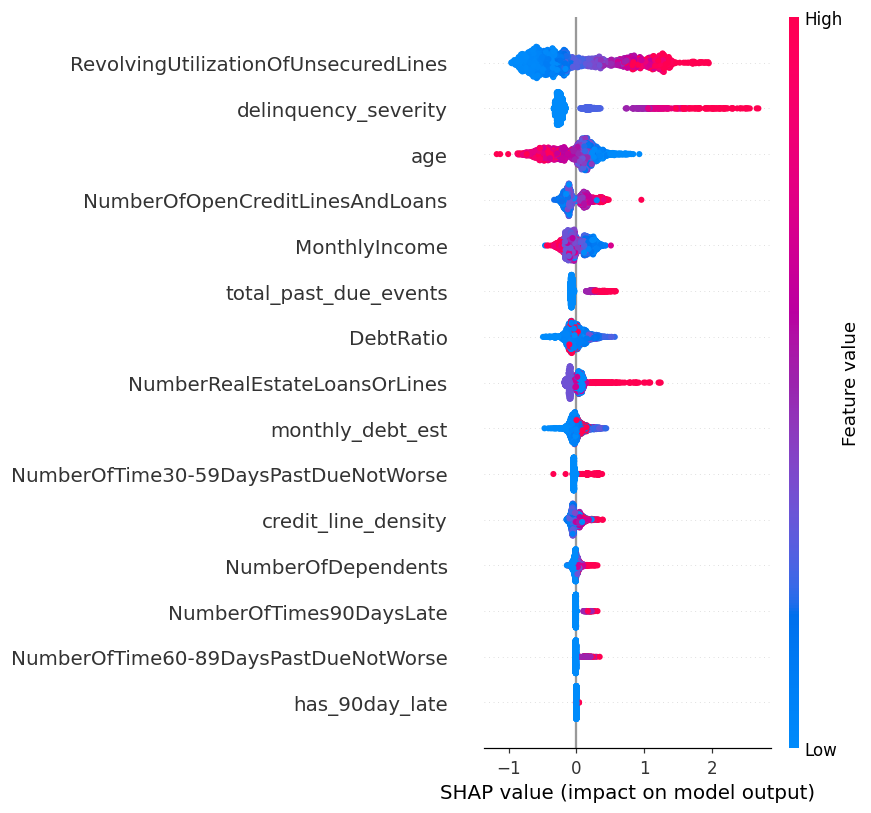

In [3]:
sample_idx = X_test.sample(2000, random_state=42).index
X_sample = X_test.loc[sample_idx]

# shap.Explainer is the unified API that works with XGBoost 3.x
explainer = shap.Explainer(xgb, X_sample)
shap_values = explainer(X_sample)

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', bbox_inches='tight')
plt.show()

## 4. SHAP Bar Chart

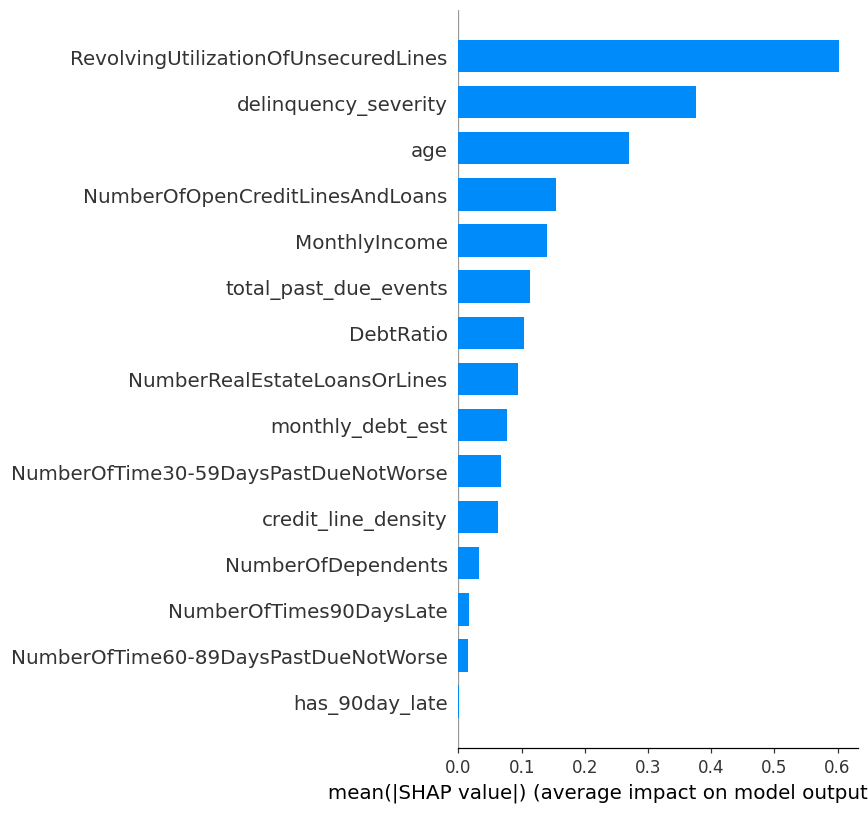

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar.png', bbox_inches='tight')
plt.show()

## 5. Individual Prediction Explanation

The waterfall plot shows how each feature pushed a specific applicant's score up or down from the baseline.

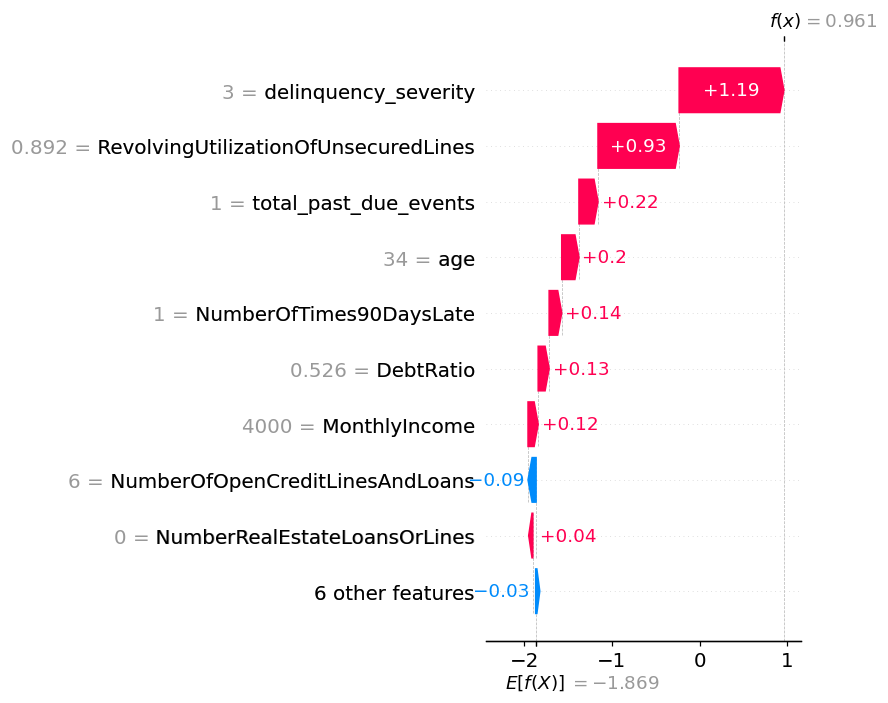

Predicted default probability: 72.34%


In [5]:
high_risk_idx = X_test.index[xgb_prob > 0.5][0]
shap_single = explainer(X_test.loc[[high_risk_idx]])
plt.figure()
shap.plots.waterfall(shap_single[0], show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_high_risk.png', bbox_inches='tight')
plt.show()
print(f"Predicted default probability: {xgb_prob[X_test.index.get_loc(high_risk_idx)]:.2%}")

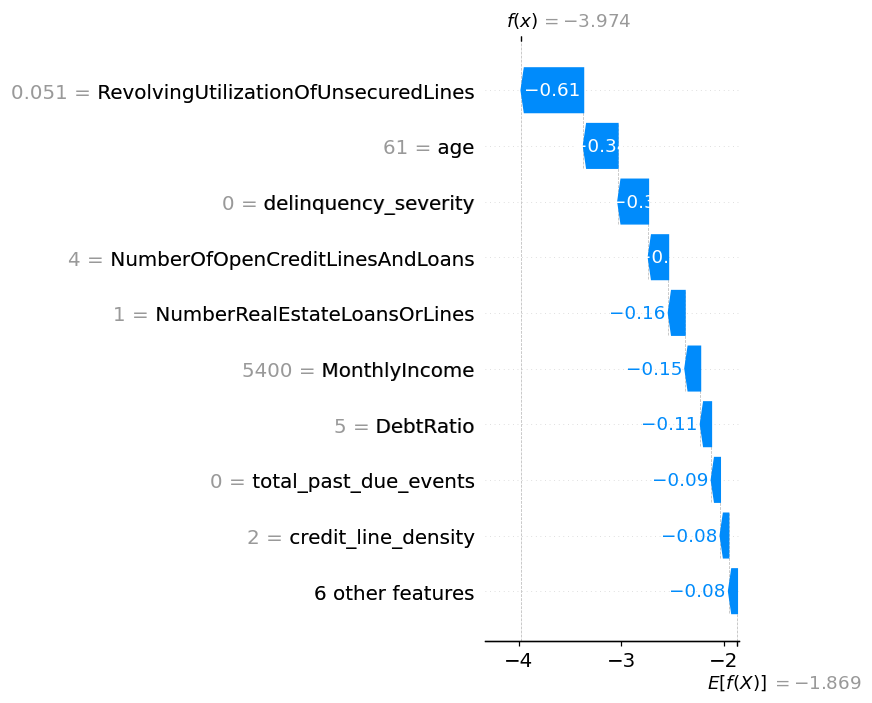

Predicted default probability: 1.84%


In [6]:
low_risk_idx = X_test.index[xgb_prob < 0.05][0]
shap_single_low = explainer(X_test.loc[[low_risk_idx]])
plt.figure()
shap.plots.waterfall(shap_single_low[0], show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_low_risk.png', bbox_inches='tight')
plt.show()
print(f"Predicted default probability: {xgb_prob[X_test.index.get_loc(low_risk_idx)]:.2%}")

## 6. Risk Band Assignment

| Risk Band | Threshold | Recommendation |
|---|---|---|
| Low | p < 10% | Approve |
| Medium | 10% <= p < 25% | Manual Review |
| High | p >= 25% | Decline |

In [7]:
risk_bands = assign_risk_bands(xgb_prob)
recommendations = recommend_action(risk_bands)

summary = risk_band_summary(y_test, xgb_prob)
print(summary.to_string(index=False))

risk_band  count  default_rate recommendation  pct_of_applicants
      Low  14297      0.008393        Approve          47.659844
   Medium   7059      0.029324  Manual Review          23.531569
     High   8642      0.194168        Decline          28.808587


/Users/ryanchang/claude/credit-default-risk/src/evaluation.py:82: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  return risk_band.map(mapping)
/Users/ryanchang/claude/credit-default-risk/src/evaluation.py:82: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  return risk_band.map(mapping)


## 7. Risk Band Visualization

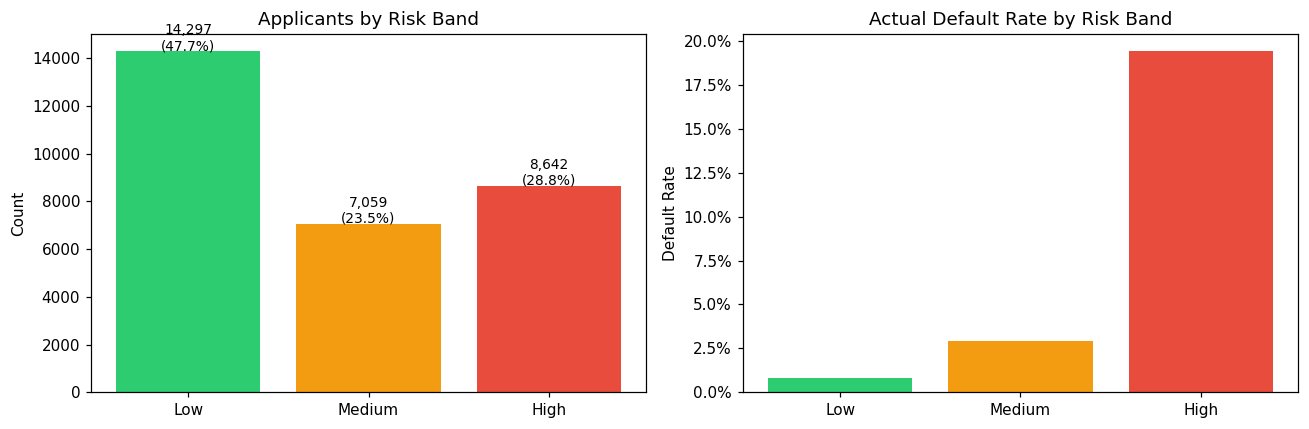

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

band_counts = risk_bands.value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(band_counts.index, band_counts.values, color=colors)
axes[0].set_title('Applicants by Risk Band')
axes[0].set_ylabel('Count')
for i, v in enumerate(band_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(risk_bands):.1%})', ha='center', fontsize=9)

band_default = summary.set_index('risk_band')['default_rate'].reindex(['Low', 'Medium', 'High'])
axes[1].bar(band_default.index, band_default.values, color=colors)
axes[1].set_title('Actual Default Rate by Risk Band')
axes[1].set_ylabel('Default Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.savefig('../outputs/figures/risk_band_summary.png', bbox_inches='tight')
plt.show()

## 8. Sample Decision Report

In [9]:
report = X_test.iloc[:10].copy()
report['predicted_default_prob'] = xgb_prob[:10]
report['risk_band'] = assign_risk_bands(xgb_prob[:10]).to_numpy()
report['recommendation'] = recommend_action(report['risk_band']).to_numpy()
report['actual_default'] = y_test.iloc[:10].values

display_cols = ['age', 'MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines',
                'predicted_default_prob', 'risk_band', 'recommendation', 'actual_default']
print(report[display_cols].to_string(index=False))

 age  MonthlyIncome  RevolvingUtilizationOfUnsecuredLines  predicted_default_prob risk_band recommendation  actual_default
  63         5970.0                              0.117364                0.053355       Low        Approve               0
  50         7816.0                              0.737316                0.350308      High        Decline               1
  56         5336.0                              0.451655                0.129359    Medium  Manual Review               0
  52         6626.0                              0.158179                0.057198       Low        Approve               0
  34         4000.0                              0.892104                0.723361      High        Decline               0
  52         4399.0                              0.031927                0.053218       Low        Approve               0
  61         5400.0                              0.050686                0.018450       Low        Approve               0
  49        1300